# 컴퓨터 비전

### 담당교수 : 장원중

#### 그래프 한글이 깨질때 & 마이너스 부호 사용

In [2]:
import sys, os
from matplotlib import font_manager, rc 
import matplotlib.pyplot as plt

# 한글 폰트 설정 : 윈도우 폰트를 사용하는 경우 
# font_name = font_manager.FontProperties(fname="c:/Windows/Fonts/malgun.ttf").get_name()
# rc('font', family=font_name) 

# 운영체제별 한글 폰트 설정
if os.name == 'posix': # Mac 환경 폰트 설정
    rc('font', family='AppleGothic')
elif os.name == 'nt': # Windows 환경 폰트 설정
    rc('font', family='Malgun Gothic')

plt.rc('axes', unicode_minus=False) # 마이너스 폰트 설정

# 유니코드에서 음수 부호설정
rc('axes', unicode_minus=False)

# 부모 디렉터리의 파일을 가져올 수 있도록 설정
sys.path.append(os.pardir)     

# jupyter에서 matplotlib 그래프를 출력 영역에 표시  
%matplotlib inline 

# 레티나 설정 - 폰트 주변이 흐릿하게 보이는 것을 방지해 글씨가 좀 더 선명하게 보임
%config InlineBackend.figure_format = 'retina'

In [2]:
# 운영체제별 이름 

import platform

platform.system()

'Windows'

# 합성 사진 만들기 

## 녹색 배경에서 찍은 인물 사진과 배경으로 사용될 이미지를 합성하기  

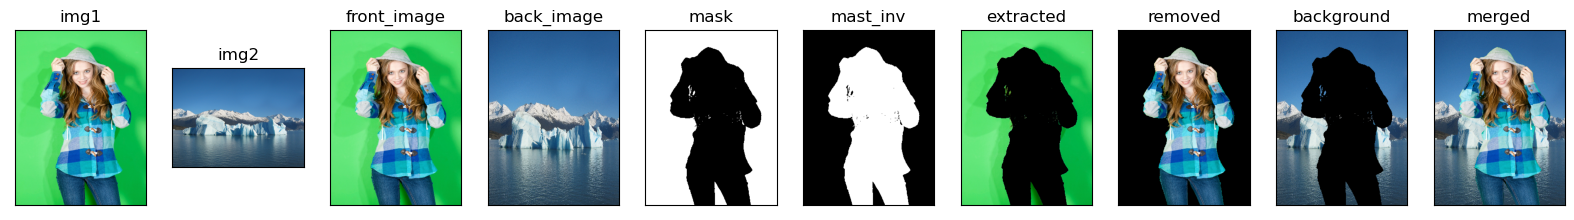

In [1]:
import numpy as np
import cv2, sys, os
from matplotlib import pyplot as plt 

img1 = cv2.imread(os.getcwd()+'/images/green_back.png', cv2.IMREAD_COLOR)   # 전경 이미지 읽기
img2 = cv2.imread(os.getcwd()+'/images/iceberg.png', cv2.IMREAD_COLOR)      # 배경 이미지 읽기
front_image = cv2.resize(img1, (300,400))
back_image = cv2.resize(img2, (300,400))

img_hsv = cv2.cvtColor(front_image, cv2.COLOR_BGR2HSV)   # HSV 공간으로 옮김
l_bound = np.array([40, 100, 50])                        # 녹색 색상의 하한
u_bound = np.array([80, 255, 255])                       # 녹색 색상의 상한

grn_mask = cv2.inRange(img_hsv, l_bound, u_bound)        # 녹색 픽셀 찾기
grn_mask_inv = cv2.bitwise_not(grn_mask)                 # 녹색이 아닌 픽셀 찾기
# grn_mask_inv = cv2.bitwise_not(mask)                     # 녹색이 아닌 픽셀 찾기

# 녹색 픽셀들만 추출하기
extracted = cv2.bitwise_and(front_image, front_image, mask=grn_mask) 

# 녹색 아닌 픽셀만 추출하기
removed = cv2.bitwise_and(front_image, front_image, mask=grn_mask_inv)   

# 녹색과 겹치는 배경 추출
background = cv2.bitwise_and(back_image, back_image, mask=grn_mask)   

# 녹색 제거 전경 + 배경   
merged = cv2.bitwise_or(removed, background)

img1_rgb = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)                 # RGB 모드로 변환
img2_rgb = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)                 # RGB 모드로 변환
front_image_rgb = cv2.cvtColor(front_image, cv2.COLOR_BGR2RGB)   # RGB 모드로 변환
back_image_rgb = cv2.cvtColor(back_image, cv2.COLOR_BGR2RGB)     # RGB 모드로 변환
grn_mask_rgb = cv2.cvtColor(grn_mask, cv2.COLOR_BGR2RGB)         # RGB 모드로 변환
grn_mask_inv_rgb = cv2.cvtColor(grn_mask_inv, cv2.COLOR_BGR2RGB) # RGB 모드로 변환
extracted_rgb = cv2.cvtColor(extracted, cv2.COLOR_BGR2RGB)       # RGB 모드로 변환
removed_rgb = cv2.cvtColor(removed, cv2.COLOR_BGR2RGB)           # RGB 모드로 변환
background_rgb = cv2.cvtColor(background, cv2.COLOR_BGR2RGB)     # RGB 모드로 변환
merged_rgb = cv2.cvtColor(merged, cv2.COLOR_BGR2RGB)             # RGB 모드로 변환

titles = ['img1','img2', 'front_image','back_image','mask','mast_inv','extracted','removed','background','merged']
images = [img1_rgb,img2_rgb,front_image_rgb,back_image_rgb,grn_mask_rgb,grn_mask_inv_rgb,extracted_rgb,removed_rgb,
          background_rgb,merged_rgb]

plt.figure(figsize=(20,20))
for i in range(10):
    plt.subplot(1,10,i+1), plt.imshow(images[i],'gray'), plt.title(titles[i]), plt.xticks([]),plt.yticks([])

plt.show()

In [2]:
import numpy as np
import cv2, sys, os
from matplotlib import pyplot as plt 

img1 = cv2.imread(os.getcwd()+'/images/green_back.png', cv2.IMREAD_COLOR)   # 전경 이미지 읽기
img2 = cv2.imread(os.getcwd()+'/images/iceberg.png', cv2.IMREAD_COLOR)      # 배경 이미지 읽기
front_image = cv2.resize(img1, (300,400))
back_image = cv2.resize(img2, (300,400))

img_hsv = cv2.cvtColor(front_image, cv2.COLOR_BGR2HSV)   # HSV 공간으로 옮김
l_bound = np.array([40, 100, 50])                        # 녹색 색상의 하한
u_bound = np.array([80, 255, 255])                       # 녹색 색상의 상한

grn_mask = cv2.inRange(img_hsv, l_bound, u_bound)        # 녹색 픽셀 찾기
grn_mask_inv = cv2.bitwise_not(grn_mask)                 # 녹색이 아닌 픽셀 찾기

# 녹색 픽셀들만 추출하기
extracted = cv2.bitwise_and(front_image, front_image, mask=grn_mask) 

# 녹색 아닌 픽셀만 추출하기
removed = cv2.bitwise_and(front_image, front_image, mask=grn_mask_inv)   

# 녹색과 겹치는 배경 추출
background = cv2.bitwise_and(back_image, back_image, mask=grn_mask)   

# 녹색 제거 전경 + 배경   
merged = cv2.bitwise_or(removed, background)

cv2.imshow('front_image', front_image)
cv2.imshow('back_image', back_image)
cv2.imshow('grn_mask', grn_mask)
cv2.imshow('grn_mask_inv', grn_mask_inv)
cv2.imshow('extracted', extracted)
cv2.imshow('removed', removed)
cv2.imshow('background', background)
cv2.imshow('merged', merged)

cv2.waitKey()                            # 사용자 입력을 기다림 
cv2.destroyAllWindows()                  # 모든 창을 없애고 프로그램 종료